# Semana 10 — RNNs, LSTMs e GRUs (PyTorch)
> Notebook completo: teoria + matemática + prática + comparação com modelos clássicos (ARIMA/ETS e baselines).

**O que você vai ver**
- Intuição de RNN / LSTM / GRU
- Matemática (BPTT, vanishing/exploding, gates)
- Treino end-to-end em PyTorch
- Previsão de série temporal (forecast)
- Comparação com modelos clássicos (naive, média móvel, ARIMA, ETS)
- Dicas de produção (quando usar o quê)


In [2]:
# Se estiver rodando no Colab, descomente:
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# !pip install statsmodels scikit-learn pandas matplotlib

import math, random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

## 1) Matemática (sem trauma, mas com fundamento)

### 1.1 RNN "vanilla"
Dada uma sequência \(x_1, x_2, \dots, x_T\), uma RNN mantém um **estado oculto**:

\[
h_t = \phi(W_{xh} x_t + W_{hh} h_{t-1} + b_h)
\]
\[
\hat{y}_t = W_{hy} h_t + b_y
\]

- \(\phi\) geralmente é \(\tanh\) ou ReLU.
- \(h_t\) é a “memória” compactada.

### 1.2 Por que dá ruim (vanishing/exploding gradient)
No backpropagation through time (BPTT), o gradiente envolve produtos repetidos do tipo:

\[
\frac{\partial \mathcal{L}}{\partial h_{t-k}}
= \frac{\partial \mathcal{L}}{\partial h_t}
\prod_{i=t-k+1}^{t} \frac{\partial h_i}{\partial h_{i-1}}
\]

E
\[
\frac{\partial h_i}{\partial h_{i-1}} \approx W_{hh}^\top \cdot \text{diag}(\phi'(a_i))
\]

Se o **raio espectral** (grosso modo: “tamanho”) de \(W_{hh}\) for < 1 e \(|\phi'|\) for pequeno (tanh satura), o produto vai → 0 (**vanishing**).  
Se for > 1, pode explodir (**exploding**).

**Conserto clássico**: *gradient clipping* (para exploding).  
**Conserto estrutural**: gates (LSTM/GRU) para vanishing.

### 1.3 LSTM (ideia)
LSTM introduz um estado de célula \(c_t\) (memória “de longo prazo”) e gates:

\[
f_t = \sigma(W_f [h_{t-1}, x_t] + b_f) \quad \text{(forget)}
\]
\[
i_t = \sigma(W_i [h_{t-1}, x_t] + b_i) \quad \text{(input)}
\]
\[
\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)
\]
\[
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
\]
\[
o_t = \sigma(W_o [h_{t-1}, x_t] + b_o) \quad \text{(output)}
\]
\[
h_t = o_t \odot \tanh(c_t)
\]

**Pulo do gato**: existe um caminho “mais linear” via \(c_t\), ajudando o gradiente a fluir por mais passos.

### 1.4 GRU (ideia)
GRU simplifica, combinando memória/célula:

\[
z_t = \sigma(W_z [h_{t-1}, x_t]) \quad \text{(update)}
\]
\[
r_t = \sigma(W_r [h_{t-1}, x_t]) \quad \text{(reset)}
\]
\[
\tilde{h}_t = \tanh(W_h [r_t \odot h_{t-1}, x_t])
\]
\[
h_t = (1 - z_t)\odot h_{t-1} + z_t \odot \tilde{h}_t
\]

Menos parâmetros → treina mais rápido, muitas vezes performa parecido com LSTM.


## 2) Dataset: série temporal sintética (com sazonalidade + ruído + choques)

A ideia aqui é ter uma série com:
- tendência leve
- sazonalidade
- ruído
- alguns “eventos” (quebras) pra deixar realista

Depois:
- transformar em janelas (windowing)
- prever o próximo valor (forecast 1-step)


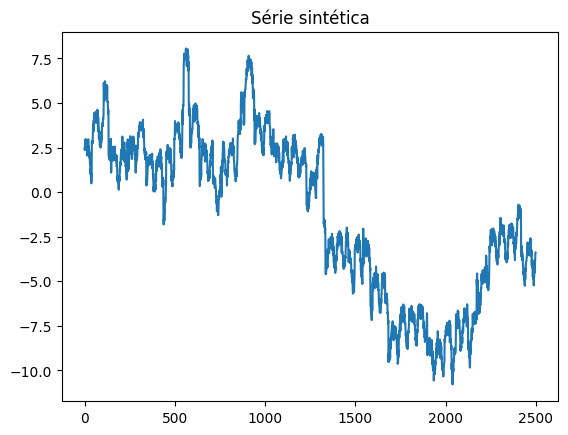

(2500, array([2.42417854, 2.35827546, 2.62776605, 2.89994769, 2.49561263]))

In [3]:
def make_time_series(n=2000, seasonal_period=50, shock_prob=0.02):
    t = np.arange(n)
    trend = 0.002 * t
    seasonal = 0.8 * np.sin(2 * np.pi * t / seasonal_period) + 0.3 * np.cos(2*np.pi*t/(seasonal_period/2))
    noise = 0.25 * np.random.randn(n)
    y = 2.0 + trend + seasonal + noise

    # choques: quedas/subidas abruptas (tipo “mudou o padrão”)
    shock = np.zeros(n)
    for i in range(1, n):
        if np.random.rand() < shock_prob:
            shock[i:] += np.random.choice([-1.5, 1.5]) * (0.5 + np.random.rand())
    y = y + shock
    return y

y = make_time_series(n=2500)
plt.figure()
plt.plot(y)
plt.title("Série sintética")
plt.show()

len(y), y[:5]


## 3) Windowing (transformar sequência em amostras supervisionadas)

Usaremos:
- `lookback`: quantos passos passados entram como input
- target: próximo passo \(y_{t+1}\)


In [4]:
class WindowedSeries(Dataset):
    def __init__(self, series, lookback=60):
        self.series = torch.tensor(series, dtype=torch.float32)
        self.lookback = lookback

    def __len__(self):
        return len(self.series) - self.lookback - 1

    def __getitem__(self, idx):
        x = self.series[idx: idx + self.lookback]          # (lookback,)
        y = self.series[idx + self.lookback]              # next value
        return x.unsqueeze(-1), y                         # x: (lookback, 1)

lookback = 60
dataset = WindowedSeries(y, lookback=lookback)

# split temporal (sem embaralhar a ordem global)
n = len(dataset)
train_end = int(n*0.7)
val_end = int(n*0.85)

train_ds = torch.utils.data.Subset(dataset, range(0, train_end))
val_ds   = torch.utils.data.Subset(dataset, range(train_end, val_end))
test_ds  = torch.utils.data.Subset(dataset, range(val_end, n))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False)

len(train_ds), len(val_ds), len(test_ds)


(1707, 366, 366)

## 4) Modelos (RNN / LSTM / GRU)

Vamos fazer modelos bem comparáveis:
- uma camada recorrente
- pega o último hidden state
- passa num `Linear` para prever o próximo valor


In [5]:
class RecurrentForecaster(nn.Module):
    def __init__(self, cell_type="lstm", input_size=1, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.cell_type = cell_type.lower()

        if self.cell_type == "rnn":
            self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers, batch_first=True, nonlinearity="tanh", dropout=dropout)
        elif self.cell_type == "gru":
            self.rnn = nn.GRU(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        elif self.cell_type == "lstm":
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        else:
            raise ValueError("cell_type must be one of: rnn, lstm, gru")

        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size//2),
            nn.ReLU(),
            nn.Linear(hidden_size//2, 1)
        )

    def forward(self, x):
        # x: (B, T, 1)
        out, _ = self.rnn(x)          # out: (B, T, H)
        last = out[:, -1, :]          # (B, H)
        yhat = self.head(last).squeeze(-1)  # (B,)
        return yhat

def train_one(model, loader, optim, loss_fn):
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optim.zero_grad(set_to_none=True)
        yhat = model(x)
        loss = loss_fn(yhat, y)
        loss.backward()
        # exploding gradient? segura o rojão:
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optim.step()
        total += loss.item() * x.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def eval_one(model, loader, loss_fn):
    model.eval()
    total = 0.0
    preds, trues = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        yhat = model(x)
        loss = loss_fn(yhat, y)
        total += loss.item() * x.size(0)
        preds.append(yhat.detach().cpu().numpy())
        trues.append(y.detach().cpu().numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    return total / len(loader.dataset), preds, trues


## 5) Treino + comparação RNN vs LSTM vs GRU

RNN | epoch 01 | train MSE 9.0699 | val MSE 34.7684
RNN | epoch 03 | train MSE 0.5350 | val MSE 0.8267
RNN | epoch 06 | train MSE 0.1963 | val MSE 0.2062
RNN | epoch 09 | train MSE 0.1994 | val MSE 0.3138
RNN | epoch 12 | train MSE 0.1821 | val MSE 0.1613
LSTM | epoch 01 | train MSE 11.6439 | val MSE 51.5735
LSTM | epoch 03 | train MSE 1.3386 | val MSE 7.6954
LSTM | epoch 06 | train MSE 0.2065 | val MSE 0.3614
LSTM | epoch 09 | train MSE 0.1917 | val MSE 0.2151
LSTM | epoch 12 | train MSE 0.1799 | val MSE 0.1574
GRU | epoch 01 | train MSE 10.8749 | val MSE 45.0462
GRU | epoch 03 | train MSE 0.8985 | val MSE 3.0430
GRU | epoch 06 | train MSE 0.1858 | val MSE 0.2534
GRU | epoch 09 | train MSE 0.1792 | val MSE 0.2632
GRU | epoch 12 | train MSE 0.1805 | val MSE 0.1565


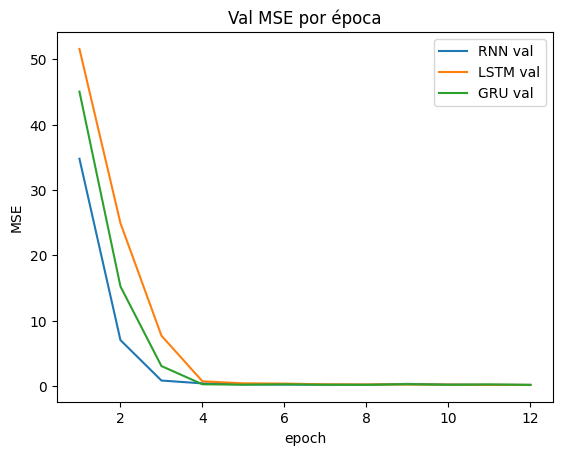

In [6]:
def fit_model(cell_type, epochs=12, hidden_size=64, lr=1e-3):
    model = RecurrentForecaster(cell_type=cell_type, hidden_size=hidden_size).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    history = []
    for ep in range(1, epochs+1):
        tr = train_one(model, train_loader, optim, loss_fn)
        va, _, _ = eval_one(model, val_loader, loss_fn)
        history.append((ep, tr, va))
        if ep in (1, 3, 6, 9, 12):
            print(f"{cell_type.upper()} | epoch {ep:02d} | train MSE {tr:.4f} | val MSE {va:.4f}")
    return model, pd.DataFrame(history, columns=["epoch","train_mse","val_mse"])

models = {}
histories = {}

for cell in ["rnn", "lstm", "gru"]:
    model, hist = fit_model(cell, epochs=12, hidden_size=64, lr=1e-3)
    models[cell] = model
    histories[cell] = hist

# plot
plt.figure()
for cell, hist in histories.items():
    plt.plot(hist["epoch"], hist["val_mse"], label=f"{cell.upper()} val")
plt.legend()
plt.title("Val MSE por época")
plt.xlabel("epoch"); plt.ylabel("MSE")
plt.show()


## 6) Avaliação no teste (PyTorch) + métricas MAE/RMSE

In [7]:
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

test_results = []

for cell, model in models.items():
    mse, preds, trues = eval_one(model, test_loader, nn.MSELoss())
    mae, rmse = metrics(trues, preds)
    test_results.append({"model": cell.upper(), "MSE": mse, "MAE": mae, "RMSE": rmse})

pd.DataFrame(test_results).sort_values("RMSE")


,model,MSE,MAE,RMSE
0,RNN,0.163957,0.296549,0.404915
1,LSTM,0.168454,0.306054,0.410431
2,GRU,0.178040,0.314404,0.421948


## 7) Modelos clássicos (baselines + ARIMA + ETS)

Aqui é onde muita gente se surpreende: **em séries simples, modelos clássicos podem bater redes** (e bem mais rápido).

Vamos comparar:
- Naive (último valor)
- Média móvel
- ARIMA
- Exponential Smoothing (ETS)

⚠️ Importante: como nosso dataset é windowed, vamos reconstruir a série de teste contígua e prever 1-step à frente com cada abordagem.


In [8]:
# reconstruindo índices para o pedaço de teste na série original
# dataset[i] pega x = y[i : i+lookback] e target = y[i+lookback]
# o conjunto test_ds usa índices [val_end, n)
test_start_i = val_end
test_end_i = n

# targets de teste em termos de posição na série original:
targets_positions = np.arange(test_start_i + lookback, test_end_i + lookback)  # alinhamento
y_test = y[targets_positions]

# inputs anteriores imediatos: último ponto do window (equivale a y[t-1] pro target y[t])
y_prev = y[targets_positions - 1]

# baseline naive: prever próximo como último valor observado
pred_naive = y_prev.copy()

# média móvel (window = lookback)
pred_ma = []
for pos in targets_positions:
    pred_ma.append(y[pos - lookback:pos].mean())
pred_ma = np.array(pred_ma)

mae_naive, rmse_naive = metrics(y_test, pred_naive)
mae_ma, rmse_ma = metrics(y_test, pred_ma)

mae_naive, rmse_naive, mae_ma, rmse_ma


(0.31010733679596564,
 0.42153285023627146,
 0.8892492893734021,
 1.1023522737456444)

In [11]:
# ARIMA e ETS: vamos ajustar no trecho de treino+val (antes do teste) e fazer forecast 1-step rolling
# Para simplificar, treinamos uma vez e fazemos previsão dinâmica (isso não é o rolling perfeito,
# mas dá uma boa noção comparativa).

trainval_end_pos = targets_positions[0]  # primeiro ponto do teste
y_trainval = y[:trainval_end_pos]

# ARIMA: escolha simples (p,d,q) = (3,0,1) (pode brincar com AIC depois)
arima = ARIMA(y_trainval, order=(3,0,1)).fit()

# ETS: tendência + sazonalidade (ajuste leve)
ets = ExponentialSmoothing(y_trainval, trend="add", seasonal="add", seasonal_periods=50).fit()

# Forecast para todo o horizonte do teste
# Envolver com np.asarray() previne erros independentemente de o retorno ser DataFrame, Series ou já um ndarray
pred_arima = np.asarray(arima.forecast(steps=len(y_test)))
pred_ets = np.asarray(ets.forecast(steps=len(y_test)))

mae_arima, rmse_arima = metrics(y_test, pred_arima)
mae_ets, rmse_ets = metrics(y_test, pred_ets)

(mae_arima, rmse_arima, mae_ets, rmse_ets)


(3.166679540082353, 3.452129971990123, 5.64598136135741, 6.022172021521761)

In [12]:
# Comparando tudo junto (inclui o melhor deep model)
deep_best = min(test_results, key=lambda d: d["RMSE"])
deep_best_name = deep_best["model"].lower()
_, deep_preds, deep_trues = eval_one(models[deep_best_name], test_loader, nn.MSELoss())

rows = [
    {"model":"NAIVE (último valor)", "MAE": mae_naive, "RMSE": rmse_naive},
    {"model":f"MÉDIA MÓVEL (w={lookback})", "MAE": mae_ma, "RMSE": rmse_ma},
    {"model":"ARIMA(3,0,1)", "MAE": mae_arima, "RMSE": rmse_arima},
    {"model":"ETS (trend+seasonal)", "MAE": mae_ets, "RMSE": rmse_ets},
    {"model":f"{deep_best['model']} (PyTorch)", "MAE": deep_best["MAE"], "RMSE": deep_best["RMSE"]},
]
df_cmp = pd.DataFrame(rows).sort_values("RMSE")
df_cmp


,model,MAE,RMSE
4,RNN (PyTorch),0.296549,0.404915
0,NAIVE (último valor),0.310107,0.421533
1,MÉDIA MÓVEL (w=60),0.889249,1.102352
2,"ARIMA(3,0,1)",3.166680,3.452130
3,ETS (trend+seasonal),5.645981,6.022172


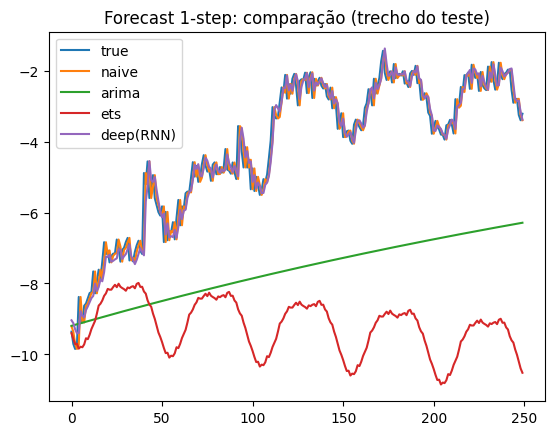

In [13]:
# Plot visual (um trecho do teste)
k = 250
plt.figure()
plt.plot(y_test[:k], label="true")
plt.plot(pred_naive[:k], label="naive")
plt.plot(pred_arima[:k], label="arima")
plt.plot(pred_ets[:k], label="ets")
plt.plot(deep_preds[:k], label=f"deep({deep_best['model']})")
plt.legend()
plt.title("Forecast 1-step: comparação (trecho do teste)")
plt.show()


## 8) Quando usar modelos clássicos vs RNN/LSTM/GRU (regra de bolso)

**Modelos clássicos (ARIMA/ETS) vencem quando:**
- série é “bem comportada”: sazonalidade/tendência relativamente estáveis
- pouco dado
- você quer interpretabilidade / rapidez
- você quer baseline forte e simples

**RNN/LSTM/GRU fazem sentido quando:**
- você tem MUITOS exemplos e padrões não-lineares
- múltiplas variáveis (multivariado) e relações complexas
- contexto longo importa (mudança de regime, dependências distantes)
- você quer aprender representações (embeddings de sequências)

**Dica de engenharia**: sempre comece por baseline + clássico → depois deep.

**E em 2026?**  
Pra muitas tarefas, Transformers (e variantes) também entram forte. Mas dominar LSTM/GRU é tipo saber OOP antes de metaprogramação: te deixa perigoso do bem.